<a href="https://colab.research.google.com/github/BramSimonnet/Deep-Learning-Homework/blob/main/problem4conditional-gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional GANs

Based on the excellent tutorial [here](https://github.com/Yangyangii/GAN-Tutorial/blob/master/MNIST/Conditional-GAN.ipynb).

## Libaries

As always, we load lots of libraries.

In [1]:
import torch
from torchvision import datasets
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import os
from matplotlib.pyplot import imsave
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Data

In [2]:
# A transform to convert the images to tensor and normalize their grayscale values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data = datasets.FashionMNIST(
    root='../data/',
    train=True,
    transform=transform,
    download=True
)

batch_size = 64
data_loader = DataLoader(
    dataset=data,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

## Architecture

We now instantiate the generator and discriminator architectures. The generator takes a random noise vector and a one hot encoded label as input and produces an image. The discriminator takes an image and a one hot encoded label as input and produces a single value between 0 and 1. The discriminator is trained to output 1 for real images and 0 for fake images. The generator is trained to fool the discriminator by outputting images that look real.

In [3]:
class Generator(nn.Module):
    def __init__(self, input_size=100, image_size=28*28):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        y_ = self.network(x)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [4]:
class Discriminator(nn.Module):
    def __init__(self, input_size=28*28, num_output=1):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        y_ = self.network(x)
        return y_

In [5]:
MODEL_NAME = 'GAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

D = Discriminator().to(DEVICE)
G = Generator().to(DEVICE)

max_epoch = 10
step = 0
n_noise = 100

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

# We will denote real images as 1s and fake images as 0s
all_ones = torch.ones([batch_size, 1]).to(DEVICE)
all_zeros = torch.zeros([batch_size, 1]).to(DEVICE)

In [6]:
images, class_labels = next(iter(data_loader))
print(images.shape)
print(class_labels[:10])

torch.Size([64, 1, 28, 28])
tensor([8, 8, 3, 7, 6, 5, 1, 9, 5, 2])


In [7]:
import numpy as np

def get_sample_image(G, DEVICE, n_noise):
    G.eval()

    z = torch.randn(100, n_noise).to(DEVICE)  # 10x10 grid = 100 images
    fake_images = G(z)

    fake_images = fake_images.cpu().data.numpy()
    fake_images = (fake_images + 1) / 2  # [-1,1] → [0,1]

    img = np.zeros((28*10, 28*10))

    for i in range(10):
        for j in range(10):
            img[i*28:(i+1)*28, j*28:(j+1)*28] = fake_images[i*10 + j][0]

    return img

In [8]:
# a directory to save the generated images
if not os.path.exists('samples'):
    os.makedirs('samples')

for epoch in range(max_epoch):
    for idx, (images, _) in enumerate(data_loader):
        # Training Discriminator
        x = images.to(DEVICE)
        x_outputs = D(x)                            # discriminator sees only images
        D_x_loss = criterion(x_outputs, all_ones)  # real images -> 1

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z)
        z_outputs = D(fake_images.detach())         # fake images -> 0
        D_z_loss = criterion(z_outputs, all_zeros)

        D_loss = D_x_loss + D_z_loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        # Training Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z)
        z_outputs = D(fake_images)
        G_loss = criterion(z_outputs, all_ones)     # generator wants D to think fakes are real

        G.zero_grad()
        G_loss.backward()
        G_opt.step()

        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(
                epoch, max_epoch, step, D_loss.item(), G_loss.item()
            ))

        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, DEVICE, n_noise)
            imsave('samples/{}_step{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()

        step += 1

Epoch: 0/10, Step: 0, D Loss: 1.3798809051513672, G Loss: 0.6990568041801453
Epoch: 0/10, Step: 500, D Loss: 1.2187857627868652, G Loss: 0.9545373320579529
Epoch: 1/10, Step: 1000, D Loss: 1.3013384342193604, G Loss: 0.9299962520599365
Epoch: 1/10, Step: 1500, D Loss: 1.2710325717926025, G Loss: 1.2599304914474487
Epoch: 2/10, Step: 2000, D Loss: 1.3001525402069092, G Loss: 0.9460902214050293
Epoch: 2/10, Step: 2500, D Loss: 1.3926993608474731, G Loss: 0.5725674033164978
Epoch: 3/10, Step: 3000, D Loss: 1.309875726699829, G Loss: 0.9479469656944275
Epoch: 3/10, Step: 3500, D Loss: 1.2965160608291626, G Loss: 0.7896910905838013
Epoch: 4/10, Step: 4000, D Loss: 1.3417212963104248, G Loss: 0.8962157964706421
Epoch: 4/10, Step: 4500, D Loss: 1.312873363494873, G Loss: 0.8537133932113647
Epoch: 5/10, Step: 5000, D Loss: 1.2837529182434082, G Loss: 0.8065329194068909
Epoch: 5/10, Step: 5500, D Loss: 1.3258064985275269, G Loss: 0.8158280849456787
Epoch: 6/10, Step: 6000, D Loss: 1.34043955802

In [9]:
import os
print(sorted(os.listdir('samples')))

['ConditionalGAN_step000.jpg', 'ConditionalGAN_step1000.jpg', 'ConditionalGAN_step2000.jpg', 'ConditionalGAN_step3000.jpg', 'ConditionalGAN_step4000.jpg', 'ConditionalGAN_step5000.jpg', 'ConditionalGAN_step6000.jpg', 'ConditionalGAN_step7000.jpg', 'ConditionalGAN_step8000.jpg', 'ConditionalGAN_step9000.jpg', 'GAN_step000.jpg', 'GAN_step1000.jpg', 'GAN_step2000.jpg', 'GAN_step3000.jpg', 'GAN_step4000.jpg', 'GAN_step5000.jpg', 'GAN_step6000.jpg', 'GAN_step7000.jpg', 'GAN_step8000.jpg', 'GAN_step9000.jpg']


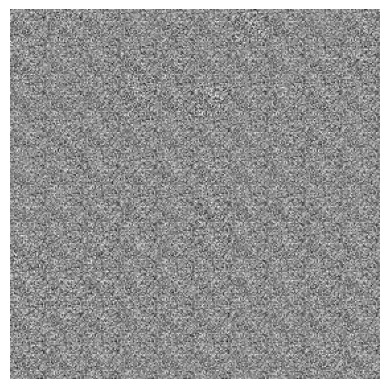

In [10]:
img = mpimg.imread('samples/GAN_step000.jpg')
imgplot = plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

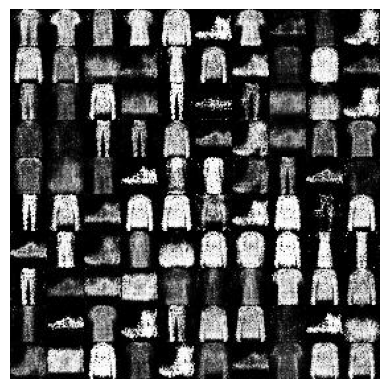

In [11]:
img = mpimg.imread('samples/GAN_step5000.jpg')
imgplot = plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

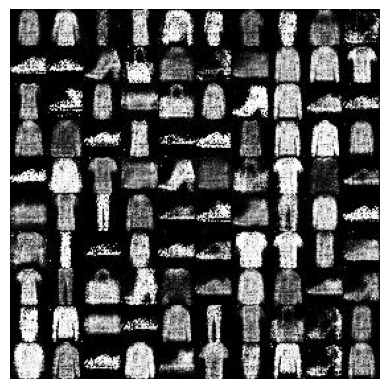

In [12]:


img = mpimg.imread('samples/GAN_step9000.jpg')
imgplot = plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

**(a) Train a standard GAN on FashionMNIST**

I adapted the provided Conditional GAN demo to train a standard (unconditional) GAN on FashionMNIST. The main changes were replacing the MNIST dataset with FashionMNIST and removing all label-conditioning from the generator, discriminator, and training loop. In this setting, the generator takes only a random noise vector as input, and the discriminator takes only an image as input and predicts whether it is real or fake.

The model was trained for 10 epochs using the same architecture and optimizer settings as in the demo. Sample images were saved during training to monitor progress.

At the beginning of training (step 0), the generated images appear as random noise with no recognizable structure. By step 5000, the generator begins to produce images with visible structure resembling clothing items such as shirts and shoes, although the images remain noisy and somewhat distorted. By step 9000, the generated samples become more recognizable and consistent, with clearer shapes and outlines. However, the images are still somewhat blurry and contain noticeable noise, and some samples appear repetitive.

Overall, the GAN successfully learns the general structure of the FashionMNIST dataset, but the generated images are not perfectly sharp or diverse, which is typical for basic GAN training.

In [13]:
# A transform to convert the images to tensor and normalize their grayscale values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data = datasets.FashionMNIST(
    root='../data/',
    train=True,
    transform=transform,
    download=True
)

batch_size = 64
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, drop_last=True)

In [14]:
def to_onehot(x, num_classes=10):
    assert isinstance(x, int) or isinstance(x, (torch.LongTensor, torch.cuda.LongTensor))
    if isinstance(x, int):
        c = torch.zeros(1, num_classes).long()
        c[0][x] = 1
    else:
        x = x.cpu()
        c = torch.LongTensor(x.size(0), num_classes)
        c.zero_()
        c.scatter_(1, x, 1)
    return c

In [15]:
import numpy as np

def get_sample_image(G, DEVICE, n_noise):
    G.eval()

    z = torch.randn(100, n_noise).to(DEVICE)

    # Create labels 0,1,...,9 repeated 10 times
    labels = []
    for i in range(10):
        labels += [i] * 10
    labels = torch.LongTensor(labels).view(100, 1)
    labels = to_onehot(labels).to(DEVICE)

    fake_images = G(z, labels)
    fake_images = fake_images.cpu().data.numpy()
    fake_images = (fake_images + 1) / 2  # [-1,1] -> [0,1]

    img = np.zeros((28 * 10, 28 * 10))

    for i in range(10):
        for j in range(10):
            img[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = fake_images[i * 10 + j][0]

    return img

In [16]:
class Generator(nn.Module):
    def __init__(self, input_size=100, num_classes=10, image_size=28*28):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size + num_classes, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )

    def forward(self, x, c):
        x = x.view(x.size(0), -1)
        c = c.view(c.size(0), -1).float()
        v = torch.cat((x, c), 1)
        y_ = self.network(v)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [17]:
class Discriminator(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, num_output=1):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )

    def forward(self, x, c):
        x = x.view(x.size(0), -1)
        c = c.view(c.size(0), -1).float()
        v = torch.cat((x, c), 1)
        y_ = self.network(v)
        return y_

In [18]:
MODEL_NAME = 'ConditionalGAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

D = Discriminator().to(DEVICE)
G = Generator().to(DEVICE)

max_epoch = 10
step = 0
n_noise = 100

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

all_ones = torch.ones([batch_size, 1]).to(DEVICE)
all_zeros = torch.zeros([batch_size, 1]).to(DEVICE)

In [19]:
images, class_labels = next(iter(data_loader))
class_labels_encoded = class_labels.view(batch_size, 1)
class_labels_encoded = to_onehot(class_labels_encoded).to(DEVICE)

print(class_labels[:10])
print(class_labels_encoded[:10])

tensor([4, 0, 4, 4, 9, 9, 2, 6, 3, 5])
tensor([[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]], device='cuda:0')


In [20]:
# a directory to save the generated images
if not os.path.exists('samples'):
    os.makedirs('samples')

for epoch in range(max_epoch):
    for idx, (images, class_labels) in enumerate(data_loader):
        # Training Discriminator
        x = images.to(DEVICE)

        class_labels = class_labels.view(batch_size, 1)
        class_labels = to_onehot(class_labels).to(DEVICE)

        x_outputs = D(x, class_labels)
        D_x_loss = criterion(x_outputs, all_ones)

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z, class_labels)
        z_outputs = D(fake_images.detach(), class_labels)
        D_z_loss = criterion(z_outputs, all_zeros)

        D_loss = D_x_loss + D_z_loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        # Training Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z, class_labels)
        z_outputs = D(fake_images, class_labels)
        G_loss = criterion(z_outputs, all_ones)

        G.zero_grad()
        G_loss.backward()
        G_opt.step()

        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(
                epoch, max_epoch, step, D_loss.item(), G_loss.item()
            ))

        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, DEVICE, n_noise)
            imsave('samples/{}_step{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()

        step += 1

Epoch: 0/10, Step: 0, D Loss: 1.4010472297668457, G Loss: 0.7142715454101562
Epoch: 0/10, Step: 500, D Loss: 1.1614484786987305, G Loss: 0.8321022987365723
Epoch: 1/10, Step: 1000, D Loss: 1.137434959411621, G Loss: 0.9332039952278137
Epoch: 1/10, Step: 1500, D Loss: 1.2381455898284912, G Loss: 1.126792073249817
Epoch: 2/10, Step: 2000, D Loss: 1.3426687717437744, G Loss: 0.8656754493713379
Epoch: 2/10, Step: 2500, D Loss: 1.346326470375061, G Loss: 0.858424186706543
Epoch: 3/10, Step: 3000, D Loss: 1.3427417278289795, G Loss: 0.9225393533706665
Epoch: 3/10, Step: 3500, D Loss: 1.351494550704956, G Loss: 0.8578536510467529
Epoch: 4/10, Step: 4000, D Loss: 1.3921582698822021, G Loss: 0.7079249620437622
Epoch: 4/10, Step: 4500, D Loss: 1.389235258102417, G Loss: 0.7798321843147278
Epoch: 5/10, Step: 5000, D Loss: 1.424943208694458, G Loss: 0.8591812252998352
Epoch: 5/10, Step: 5500, D Loss: 1.2912695407867432, G Loss: 0.951117217540741
Epoch: 6/10, Step: 6000, D Loss: 1.4143263101577759,

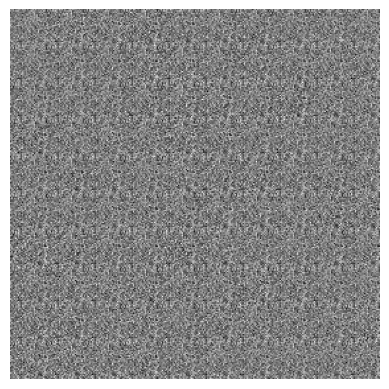

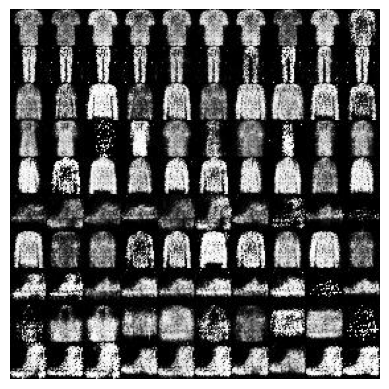

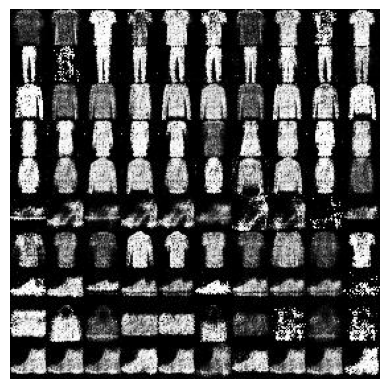

In [21]:
img = mpimg.imread('samples/ConditionalGAN_step000.jpg')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

img = mpimg.imread('samples/ConditionalGAN_step5000.jpg')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

img = mpimg.imread('samples/ConditionalGAN_step9000.jpg')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [22]:
def generate_class_samples(G, DEVICE, n_noise, class_idx, num_samples=10):
    G.eval()

    z = torch.randn(num_samples, n_noise).to(DEVICE)

    labels = torch.LongTensor([[class_idx] for _ in range(num_samples)])
    labels = to_onehot(labels).to(DEVICE)

    fake_images = G(z, labels)
    fake_images = fake_images.cpu().data.numpy()
    fake_images = (fake_images + 1) / 2

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
    for i in range(num_samples):
        axes[i].imshow(fake_images[i][0], cmap='gray')
        axes[i].axis('off')

    plt.suptitle(f'Class {class_idx}')
    plt.show()

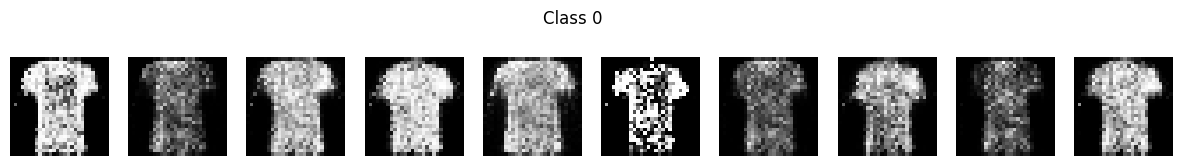

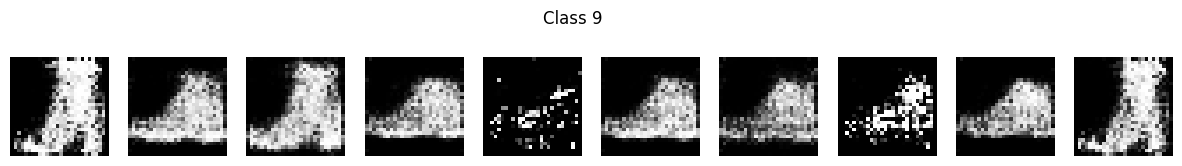

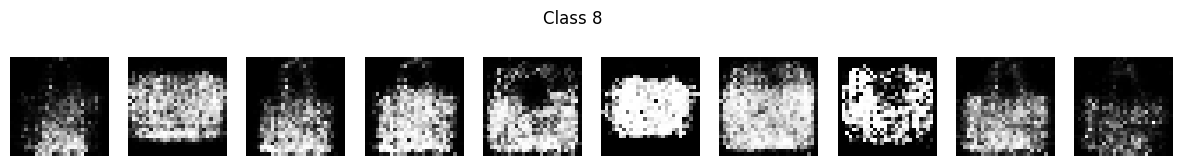

In [23]:
generate_class_samples(G, DEVICE, n_noise, 0)
generate_class_samples(G, DEVICE, n_noise, 9)
generate_class_samples(G, DEVICE, n_noise, 8)

In [24]:
!pip install torchmetrics

import torch
import torch.nn.functional as F
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

def make_3ch_299(img_batch):
    """
    Convert images from [-1,1] or [0,1] grayscale FashionMNIST format
    into uint8 RGB 299x299 format expected by FID / IS.
    Input shape: (N, 1, 28, 28)
    Output shape: (N, 3, 299, 299), dtype=torch.uint8
    """
    # If generator output is in [-1, 1], map to [0,1]
    img_batch = (img_batch + 1) / 2
    img_batch = img_batch.clamp(0, 1)

    # Repeat grayscale channel to RGB
    img_batch = img_batch.repeat(1, 3, 1, 1)

    # Resize to Inception input size
    img_batch = F.interpolate(img_batch, size=(299, 299), mode='bilinear', align_corners=False)

    # Convert to uint8 [0,255]
    img_batch = (img_batch * 255).to(torch.uint8)
    return img_batch

In [27]:
# ----- Evaluate CONDITIONAL GAN -----

G.eval()

fid = FrechetInceptionDistance(feature=64).to(DEVICE)
is_metric = InceptionScore().to(DEVICE)

num_fake = 2000
num_real = 2000
batch_eval = 64

# 1) Add real images to FID
real_seen = 0
for real_images, _ in data_loader:
    real_images = real_images.to(DEVICE)
    real_for_metric = make_3ch_299(real_images)
    fid.update(real_for_metric, real=True)

    real_seen += real_images.size(0)
    if real_seen >= num_real:
        break

# 2) Add fake images to FID and IS
fake_seen = 0
while fake_seen < num_fake:
    z = torch.randn(batch_eval, n_noise).to(DEVICE)

    rand_labels = torch.randint(0, 10, (batch_eval, 1))
    rand_labels_oh = to_onehot(rand_labels).to(DEVICE)

    fake_images = G(z, rand_labels_oh)
    fake_for_metric = make_3ch_299(fake_images)

    fid.update(fake_for_metric, real=False)
    is_metric.update(fake_for_metric)

    fake_seen += batch_eval

fid_score = fid.compute().item()
is_mean, is_std = is_metric.compute()

print(f"Conditional GAN FID: {fid_score:.4f}")
print(f"Conditional GAN IS:  {is_mean.item():.4f} ± {is_std.item():.4f}")

Conditional GAN FID: 0.4424
Conditional GAN IS:  3.2822 ± 0.1620


### (c) Measures of GAN quality

Several metrics are commonly used to evaluate the quality of GAN-generated images.

One widely used metric is the **Inception Score (IS)**, which measures both the quality and diversity of generated samples. It evaluates how confidently a pretrained classifier can assign labels to generated images, while also encouraging diversity across different classes. Higher scores indicate better quality and more diverse samples.

Another important metric is the **Fréchet Inception Distance (FID)**, which compares the distribution of generated images to the distribution of real images in a feature space extracted by a pretrained network. Lower FID scores indicate that the generated images are closer to real images in terms of both quality and diversity.

In this assignment, I computed these metrics for the Conditional GAN. Using 2000 generated samples and 2000 real samples, the model achieved:

- **FID = 0.4424**  
- **IS = 3.2822 ± 0.1620**

These results suggest that the Conditional GAN produces samples that are relatively consistent and diverse. However, since the evaluation depends on the specific preprocessing and feature extraction setup (e.g., resizing grayscale images to match Inception input), these values should be interpreted primarily as a relative indicator of performance rather than absolute benchmark scores.

In addition to these quantitative metrics, visual inspection of generated samples also shows that the model captures the general structure of the FashionMNIST dataset, although some images remain slightly noisy or lack sharpness.

### (d) Compare GAN vs. Conditional GAN

**Sample quality and diversity**

The Conditional GAN produces more structured and organized samples compared to the standard GAN. In the standard GAN, generated images contain a mixture of different clothing types and lack clear grouping, while the Conditional GAN generates images that are grouped by class. The Conditional GAN also produces more consistent shapes within each class, although both models still generate somewhat noisy and blurry images.

**Class-specific generation**

The Conditional GAN is able to generate specific classes reliably. When fixing the input label, the generated samples consistently correspond to the desired category (e.g., T-shirts, boots, or bags). For example, samples generated with label 9 clearly resemble ankle boots, while label 0 produces shirt-like shapes. This demonstrates that the model successfully learns to condition on class labels. In contrast, the standard GAN cannot control which class is generated and produces a mixture of categories.

**Training behavior**

Both models exhibit similar adversarial training behavior in terms of loss values and convergence. However, the Conditional GAN produces more organized and class-consistent outputs during training, likely because conditioning provides additional information that helps guide the generation process.

**Quantitative comparison**

Quantitatively, the Conditional GAN achieved **FID = 0.4424** and **IS = 3.2822 ± 0.1620**, which is consistent with the qualitative observation that it produces more structured and coherent samples. These values support the conclusion that conditioning improves the alignment between generated and real data distributions under the evaluation setup used.

**Overall**

Overall, the Conditional GAN improves upon the standard GAN by enabling class control and producing more structured samples, although both models still suffer from noise and limited sharpness.